In [ ]:
# imports 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import sklearn as sk 
import math
import tensorflow as tf
import os 
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle
import cv2
from torch.utils.data import Dataset
from PIL import Image
import torch
import torchvision.transforms as TT
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 

In [ ]:
# download data from https://www.kaggle.com/c/aptos2019-blindness-detection/overview

In [2]:
# identify global vars
num_classes = 5 
seed = 42
train_image_folder = "train_images"
test_image_folder = "test_images"

batch_size = 32

In [ ]:
# load dataset 
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")   # test has no diagnosis label 


print(df_train.head(20))

         id_code  diagnosis
0   000c1434d8d7          2
1   001639a390f0          4
2   0024cdab0c1e          1
3   002c21358ce6          0
4   005b95c28852          0
5   0083ee8054ee          4
6   0097f532ac9f          0
7   00a8624548a9          2
8   00b74780d31d          2
9   00cb6555d108          1
10  00cc2b75cddd          0
11  00e4ddff966a          2
12  00f6c1be5a33          0
13  0104b032c141          3
14  0124dffecf29          1
15  0125fbd2e791          0
16  012a242ac6ff          2
17  014508ccb9cb          0
18  0151781fe50b          0
19  0161338f53cc          2


In [17]:
print(df_test.head(20))

         id_code
0   0005cfc8afb6
1   003f0afdcd15
2   006efc72b638
3   00836aaacf06
4   009245722fa4
5   009c019a7309
6   010d915e229a
7   0111b949947e
8   01499815e469
9   0167076e7089
10  01c31b10ab99
11  01c5ba195207
12  01e4d86b3a30
13  020921b796d5
14  020f6983114d
15  021c207614d6
16  0229c0a80d42
17  024d0a225db1
18  0268f4382c67
19  0299d97f31f7


In [7]:
# split train into features and labels
x = df_train['id_code']
y = df_train['diagnosis']

diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


C:\Users\adria\AppData\Local\Temp\ipykernel_4672\1990889102.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="hls")


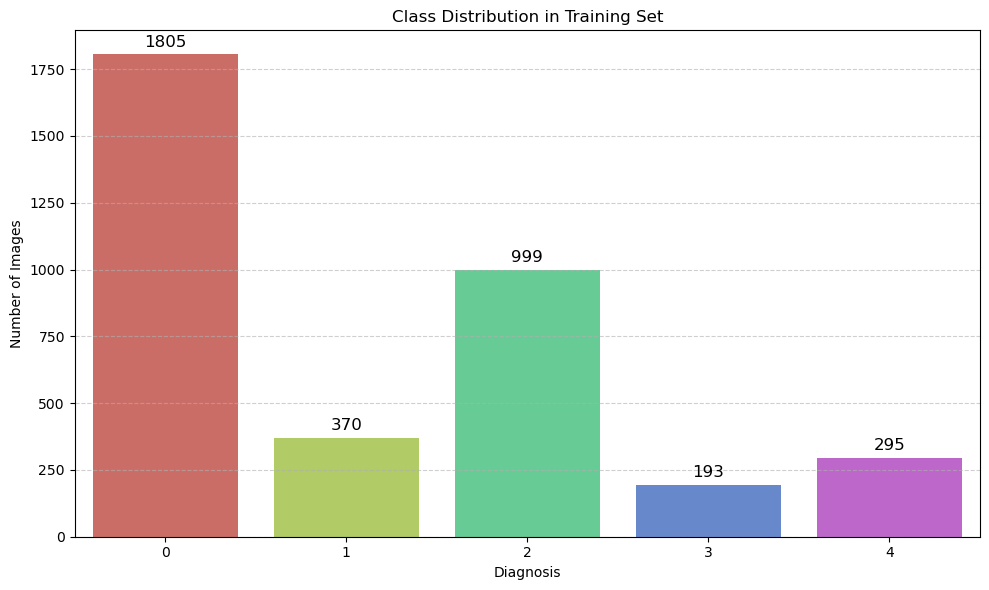

In [16]:
# shuffle 
x, y = shuffle(x,y,random_state=seed)
df_train_shuffled = pd.DataFrame({'id_code': x, 'diagnosis': y})

x_test = df_test['id_code']
df_test_clean = pd.DataFrame({'id_code': x_test})  # No 'diagnosis' column


# Count number of samples in each class (for training only)
class_counts = df_train_shuffled['diagnosis'].value_counts().sort_index()
print(class_counts)

# Visualize class distribution
# Visualize class distribution
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="hls")

# Add text labels on each bar
for i, count in enumerate(class_counts.values):
    ax.text(i, count + max(class_counts.values)*0.01,   # position slightly above bar
            str(count),
            ha='center', va='bottom', fontsize=12)

plt.title("Class Distribution in Training Set")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# PREPROCESSING

def crop_image_from_gray(img, tol=7):
    """
    Crop out dark/black borders from fundus images.
    tol: threshold below which pixels are considered 'black'.
    """

    # If image is grayscale
    if img.ndim == 2:
        mask = img > tol                       # Create mask of pixels > tol
        return img[np.ix_(mask.any(1), mask.any(0))]

    # If image is colour (RGB)
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)  # Convert to grayscale for mask
        mask = gray_img > tol                              # Identify pixels above threshold

        # for safety: if mask removes entire image (extremely dark image)
        if img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0] == 0:
            return img  # Return original to avoid zero-dimension errors

        # Apply mask to each channel separately
        img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
        img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
        img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]

        # Stack channels back together
        img = np.stack([img1, img2, img3], axis=-1)
        return img


In [20]:
def ben_graham_preprocess(img, sigmaX=10):
    """
    Implements Ben Graham's illumination correction technique.
    img: RGB image
    sigmaX: Gaussian blur sigma controlling smoothing intensity
    """

    # AddWeighted performs: output = img*4 - gaussian_blur(img)*4 + 128
    # This suppresses uneven lighting and boosts local contrast.
    return cv2.addWeighted(
        img, 4,                                     # Weight original image
        cv2.GaussianBlur(img, (0, 0), sigmaX),      # Apply Gaussian blur
        -4,                                         # Subtract blurred image
        128                                         # Add constant to stabilise brightness
    )


In [21]:
def circle_crop_image(img):
    """
    Applies a circular crop centred on the image.
    Removes remaining background pixels after initial cropping.
    """

    h, w, _ = img.shape

    # Determine radius of circle (half of smallest dimension)
    radius = min(h, w) // 2  

    # Compute centre coordinates
    center = (w // 2, h // 2)

    # Build meshgrid of pixel distances from center
    Y, X = np.ogrid[:h, :w]
    dist_from_center = (X - center[0])**2 + (Y - center[1])**2

    # Mask: True = inside circle
    mask = dist_from_center <= radius**2

    # Copy and set outside-circle pixels to black
    circular = img.copy()
    circular[~mask] = 0  

    return circular


In [22]:
IMG_SIZE = 256  # choose your model input size

def load_and_preprocess(path, sigmaX=10):
    """
    Complete preprocessing pipeline:
    1. Read image
    2. Convert to RGB
    3. Auto-crop black borders
    4. Resize to standard size
    5. Optional circular crop
    6. Ben Graham illumination correction
    """

    # STEP 1: Load BGR image from OpenCV
    img = cv2.imread(path)

    # STEP 2: Convert BGR → RGB (colour-correct)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # STEP 3: Auto-crop black borders
    img = crop_image_from_gray(img)

    # STEP 4: Resize to consistent input size for CNNs
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # STEP 5: Apply circular crop (uniform framing)
    img = circle_crop_image(img)

    # STEP 6: Apply Ben Graham illumination correction
    img = ben_graham_preprocess(img, sigmaX=sigmaX)

    return img


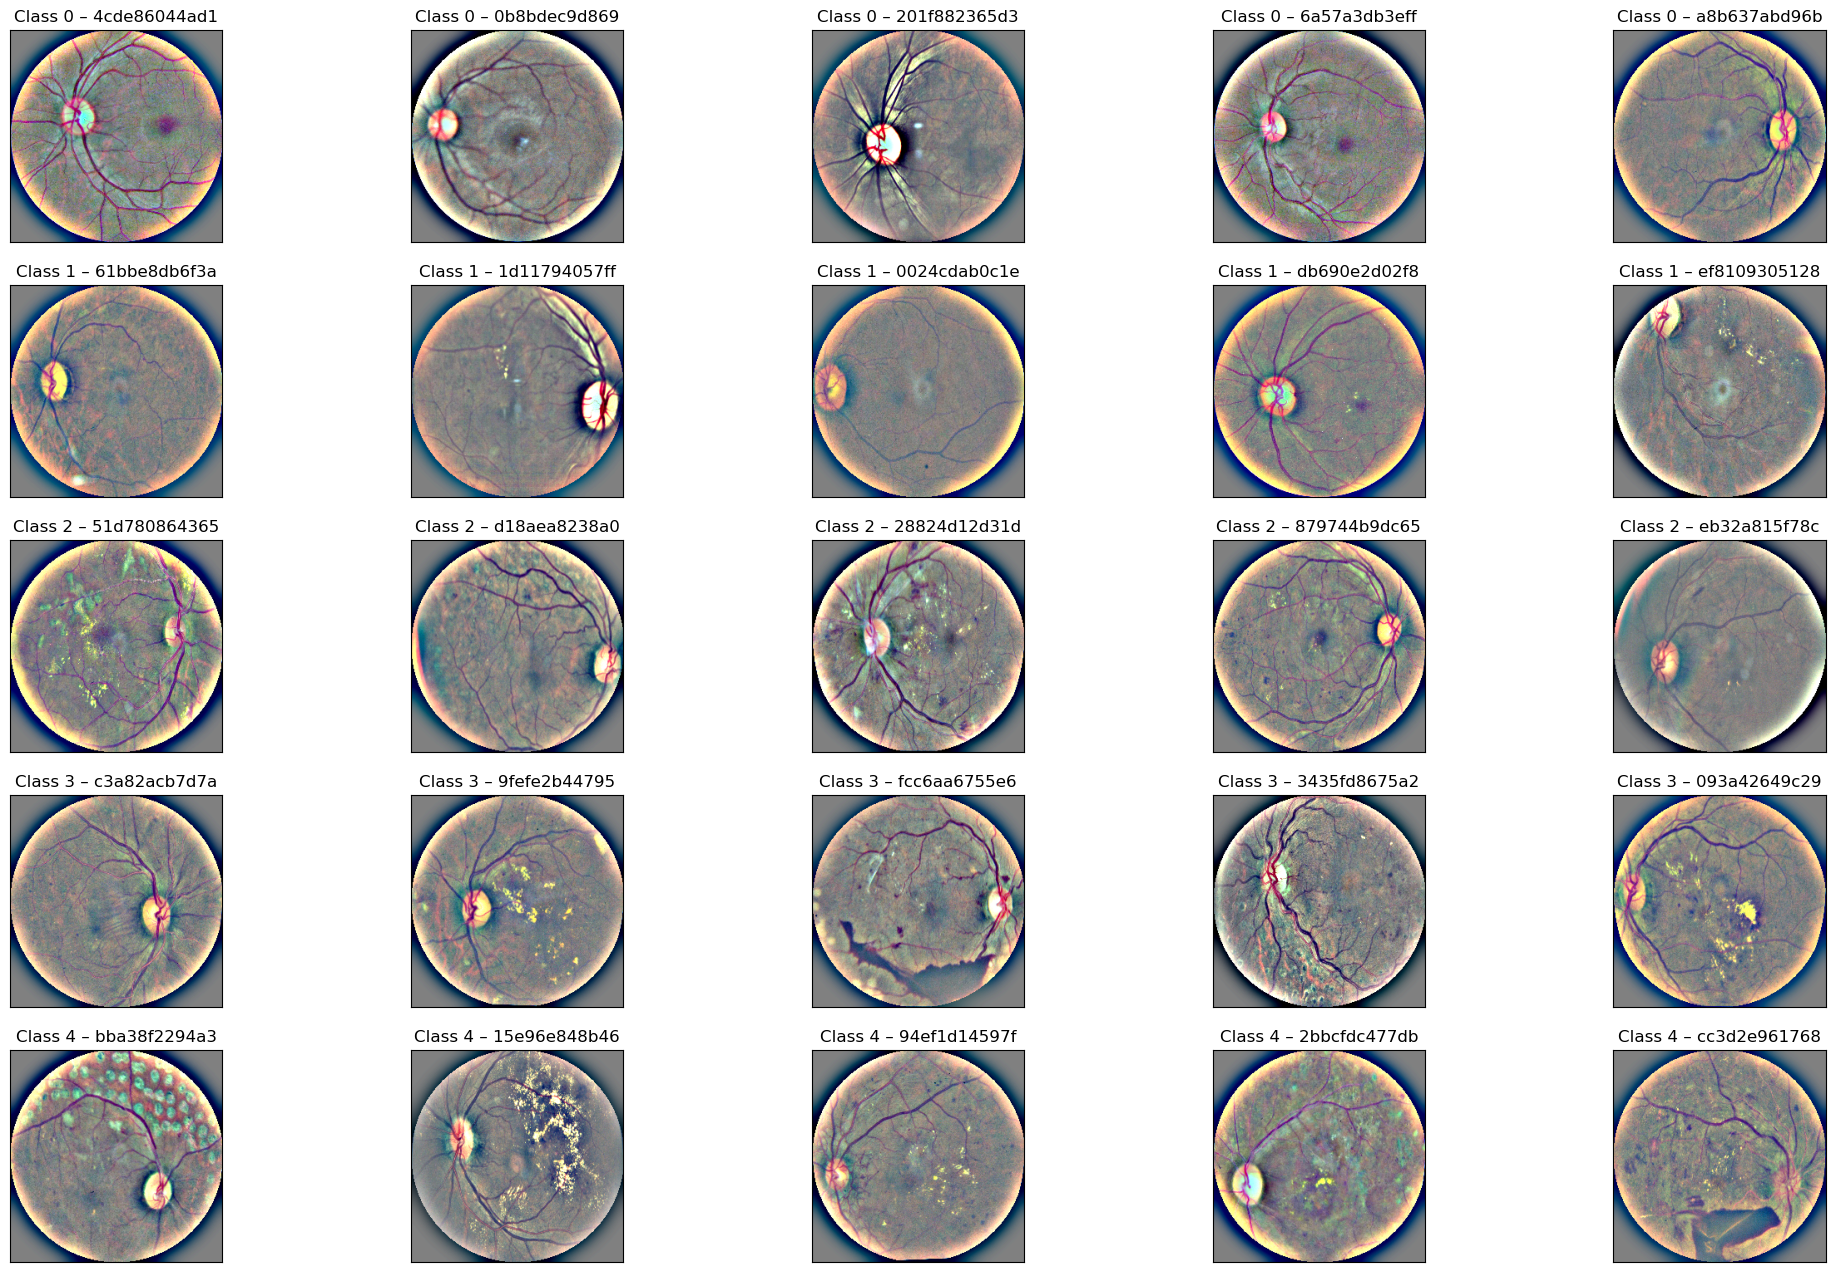

In [23]:
fig = plt.figure(figsize=(25, 16))

for class_id in sorted(df_train_shuffled['diagnosis'].unique()):
    # Sample 5 images of each class
    sample_rows = df_train_shuffled[df_train_shuffled['diagnosis'] == class_id].sample(5, random_state=seed)

    for i, (idx, row) in enumerate(sample_rows.iterrows()):
        # Create subplot grid index
        ax = fig.add_subplot(5, 5, class_id * 5 + i + 1, xticks=[], yticks=[])

        # Build file path
        path = f"{train_image_folder}/{row['id_code']}.png"

        # Apply preprocessing
        img = load_and_preprocess(path, sigmaX=10)

        # Show image
        plt.imshow(img)
        ax.set_title(f"Class {class_id} – {row['id_code']}")


In [ ]:
class DRDataset(Dataset):
    def __init__(self, df, image_folder, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get ID and label
        image_id = self.df.loc[idx, 'id_code']
        label = self.df.loc[idx, 'diagnosis']

        # Build path
        path = f"{self.image_folder}/{image_id}.png"

        # Apply preprocessing you implemented
        img = load_and_preprocess(path, sigmaX=10)

        # Convert to tensor format expected by PyTorch
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)

        return img, label


In [ ]:
train_df, val_df = train_test_split(
    df_train_shuffled,
    test_size=0.3,
    random_state=seed,
    stratify=df_train_shuffled['diagnosis']
)


In [ ]:

train_transform = TT.Compose([
    TT.RandomHorizontalFlip(),
    TT.RandomRotation(15),
    TT.ToTensor(),
])

val_transform = TT.Compose([
    TT.ToTensor()
])


In [46]:
train_dataset = DRDataset(train_df, train_image_folder, transform=train_transform)
val_dataset   = DRDataset(val_df,   train_image_folder, transform=val_transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DR_CNN(nn.Module):
    def __init__(self, num_classes=5):
        super(DR_CNN, self).__init__()

        # BLOCK 1: Low-level feature extraction
        # Conv layer 1: 32 filters, kernel 3×3 learns edges/texture
        self.conv1_1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1_1   = nn.BatchNorm2d(32)

        # Conv layer 2: 32 filters again → builds on basic shapes
        self.conv1_2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1_2   = nn.BatchNorm2d(32)

        # MaxPooling to reduce spatial size and control overfitting
        self.pool1   = nn.MaxPool2d(kernel_size=2, stride=2)



        # BLOCK 2: Mid-level feature extraction
        # Conv layer 3: 64 filters learns more complex structures
        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2_1   = nn.BatchNorm2d(64)

        # Conv layer 4: 128 filters → deeper, high-level features
        self.conv2_2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2_2   = nn.BatchNorm2d(128)

        # MaxPooling again
        self.pool2   = nn.MaxPool2d(kernel_size=2, stride=2)



        # BLOCK 3: Classification head
        # After two 2×2 poolings, IMG_SIZE reduces by factor of 4
        # For IMG_SIZE=256: 256/4 = 64 feature map size

        self.flatten = nn.Flatten()

        # Fully connected layer with 128 neurons for high-level reasoning
        self.fc1 = nn.Linear(128 * 64 * 64, 128)

        # BatchNorm stabilises activation distribution
        self.bn_fc = nn.BatchNorm1d(128)

        # Dropout 10% → prevents overfitting
        self.dropout = nn.Dropout(0.1)

        # Output layer → produce class probabilities
        self.fc_out = nn.Linear(128, num_classes)


    def forward(self, x):

        # ------- BLOCK 1 -------
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool1(x)

        # ------- BLOCK 2 -------
        x = F.relu(self.bn2_1(self.conv2_1(x)))
        x = F.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool2(x)

        # ------- BLOCK 3 -------
        x = self.flatten(x)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc_out(x)

        return x


In [ ]:
# Select GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


Using device: cpu


In [36]:
model = DR_CNN(num_classes=5).to(device)


In [38]:
import torch

# class counts from your dataset
class_counts = torch.tensor([1805, 370, 999, 193, 295], dtype=torch.float)

# inverse frequency weighting → rarer classes get higher weight
weights = 1.0 / class_counts  

# normalize to sum to 1, optional but cleaner
weights = weights / weights.sum()  

# move to correct device (GPU or CPU)
weights = weights.to(device)

print(weights)


tensor([0.0432, 0.2107, 0.0780, 0.4039, 0.2642])


In [39]:
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [40]:
from sklearn.metrics import f1_score, cohen_kappa_score, confusion_matrix
import torch
import numpy as np

In [41]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Predictions
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # Metrics
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='macro')
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    return running_loss / len(train_loader), acc, f1, qwk


In [47]:
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Metrics
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='macro')
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    cm = confusion_matrix(all_labels, all_preds)

    return running_loss / len(val_loader), acc, f1, qwk, cm


In [48]:
num_epochs = 30  # same as literature

for epoch in range(num_epochs):
    train_loss, train_acc, train_f1, train_qwk = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    val_loss, val_acc, val_f1, val_qwk, cm = validate(
        model, val_loader, criterion, device
    )

    print(f"\nEPOCH {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f} | QWK: {train_qwk:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f} | QWK: {val_qwk:.4f}")
    print("Confusion Matrix:\n", cm)



EPOCH 1/30
Train Loss: 1.4268 | Acc: 0.4932 | F1: 0.3406 | QWK: 0.4512
Val   Loss: 1.2969 | Acc: 0.5869 | F1: 0.4135 | QWK: 0.5351
Confusion Matrix:
 [[419  45  35  33  10]
 [  2  59  32  11   7]
 [ 15  83 136  43  23]
 [  2  11  20  21   4]
 [  5  26  36  11  10]]

EPOCH 2/30
Train Loss: 1.2005 | Acc: 0.6114 | F1: 0.4381 | QWK: 0.6198
Val   Loss: 1.1905 | Acc: 0.6488 | F1: 0.4505 | QWK: 0.6365
Confusion Matrix:
 [[509   6   4  10  13]
 [ 13  37  28   4  29]
 [ 35  32 113  28  92]
 [  8   2  18  12  18]
 [  9  11  19   7  42]]

EPOCH 3/30
Train Loss: 1.0757 | Acc: 0.6652 | F1: 0.5082 | QWK: 0.6979
Val   Loss: 1.1781 | Acc: 0.6606 | F1: 0.4582 | QWK: 0.7243
Confusion Matrix:
 [[520   7   5  10   0]
 [ 10  47  26  27   1]
 [ 38  37 111  97  17]
 [  5   5   8  37   3]
 [  7  10  21  39  11]]

EPOCH 4/30
Train Loss: 0.9532 | Acc: 0.7074 | F1: 0.5699 | QWK: 0.7415
Val   Loss: 1.0991 | Acc: 0.6551 | F1: 0.4826 | QWK: 0.6994
Confusion Matrix:
 [[508  14   1  11   8]
 [  7  77   7   7  13]
 [

In [ ]:
# RECONSTRUCTED METRICS FROM LOGS

train_acc = [
    0.4932, 0.6114, 0.6652, 0.7074, 0.7335,
    0.7597, 0.7803, 0.7854, 0.8084, 0.8283,
    0.8322, 0.8455, 0.8611, 0.8697, 0.8876,
    0.8775, 0.8958, 0.8935, 0.8966, 0.9067,
    0.9216, 0.9103, 0.9231, 0.9266, 0.9220,
    0.9415, 0.9458, 0.9430, 0.9426, 0.9403
]

val_acc = [
    0.5869, 0.6488, 0.6606, 0.6551, 0.6797,
    0.6242, 0.7225, 0.6806, 0.7252, 0.7416,
    0.6115, 0.7334, 0.7070, 0.7425, 0.6979,
    0.7279, 0.6806, 0.7516, 0.7534, 0.7088,
    0.7334, 0.7334, 0.7316, 0.7407, 0.7543,
    0.7134, 0.7525, 0.7279, 0.7379, 0.7361
]

train_f1 = [
    0.3406, 0.4381, 0.5082, 0.5699, 0.6061,
    0.6420, 0.6696, 0.6715, 0.7139, 0.7528,
    0.7501, 0.7717, 0.7939, 0.8022, 0.8352,
    0.8126, 0.8429, 0.8474, 0.8479, 0.8642,
    0.8858, 0.8683, 0.8891, 0.8892, 0.8867,
    0.9132, 0.9150, 0.9132, 0.9167, 0.9135
]

val_f1 = [
    0.4135, 0.4505, 0.4582, 0.4826, 0.5001,
    0.4829, 0.5208, 0.5061, 0.5435, 0.5644,
    0.4736, 0.5477, 0.5457, 0.5488, 0.5283,
    0.5271, 0.5085, 0.5593, 0.5632, 0.5218,
    0.5487, 0.5229, 0.5511, 0.5533, 0.5687,
    0.5390, 0.5603, 0.5406, 0.5471, 0.5539
]

train_qwk = [
    0.4512, 0.6198, 0.6979, 0.7415, 0.7695,
    0.8091, 0.8369, 0.8354, 0.8525, 0.8699,
    0.8669, 0.8816, 0.8895, 0.9127, 0.9235,
    0.9174, 0.9137, 0.9146, 0.9347, 0.9237,
    0.9359, 0.9335, 0.9349, 0.9475, 0.9360,
    0.9577, 0.9598, 0.9542, 0.9506, 0.9530
]

val_qwk = [
    0.5351, 0.6365, 0.7243, 0.6994, 0.6941,
    0.7228, 0.7856, 0.7569, 0.7619, 0.7803,
    0.6407, 0.7805, 0.7928, 0.7888, 0.7580,
    0.7728, 0.7066, 0.8166, 0.8142, 0.7492,
    0.7814, 0.7862, 0.7774, 0.8124, 0.7920,
    0.7760, 0.8030, 0.7869, 0.7906, 0.8055
]

epochs = range(1, 31)


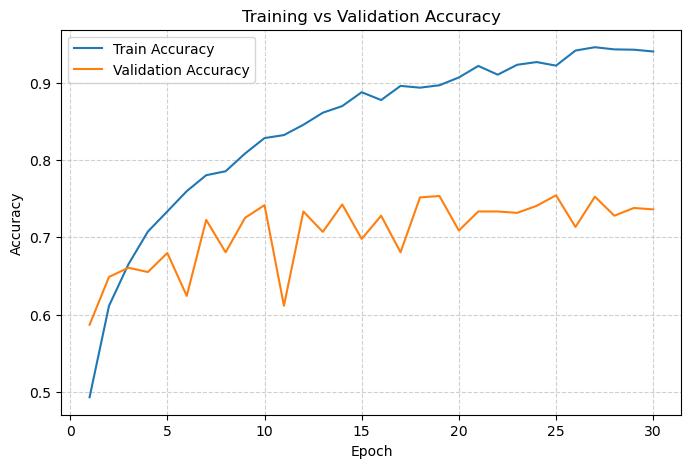

In [53]:
#Accuracy
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(linestyle='--', alpha=0.6)
plt.show()


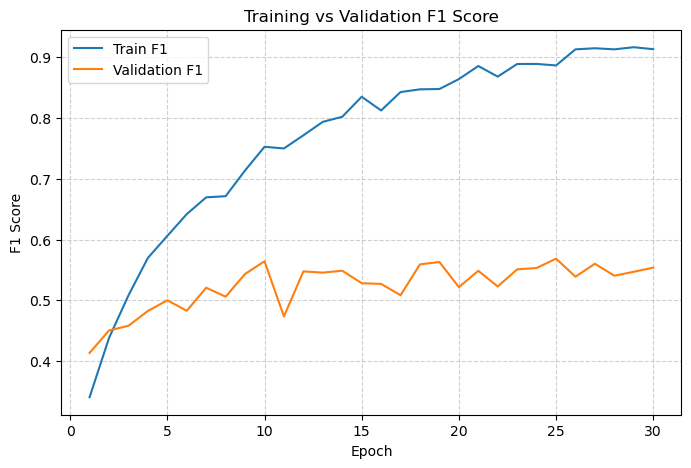

In [55]:
# f1
plt.figure(figsize=(8,5))
plt.plot(epochs, train_f1, label="Train F1")
plt.plot(epochs, val_f1, label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Training vs Validation F1 Score")
plt.legend()
plt.grid(linestyle='--', alpha=0.6)
plt.show()


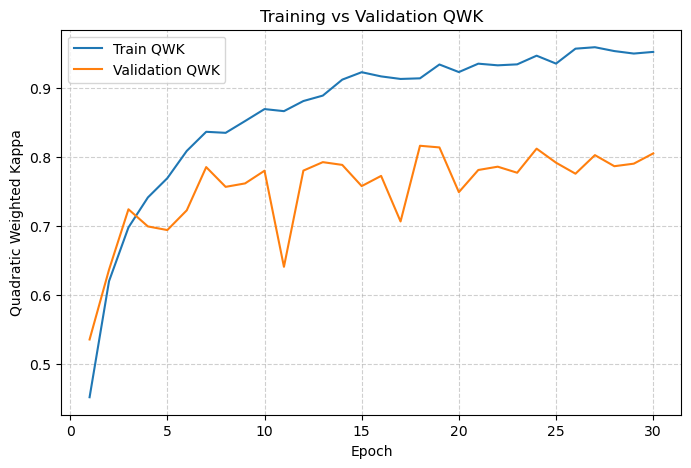

In [57]:
# QWK
plt.figure(figsize=(8,5))
plt.plot(epochs, train_qwk, label="Train QWK")
plt.plot(epochs, val_qwk, label="Validation QWK")
plt.xlabel("Epoch")
plt.ylabel("Quadratic Weighted Kappa")
plt.title("Training vs Validation QWK")
plt.legend()
plt.grid(linestyle='--', alpha=.6)
plt.show()


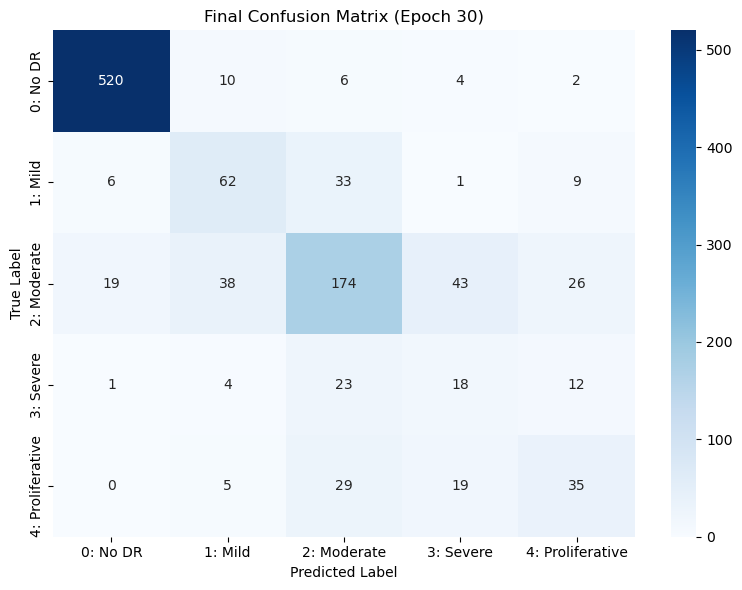

In [60]:
# Final confusion matrix from epoch 30
cm = np.array([
    [520, 10,  6,  4,  2],
    [  6, 62, 33,  1,  9],
    [ 19, 38,174, 43, 26],
    [  1,  4, 23, 18, 12],
    [  0,  5, 29, 19, 35]
])

# Class labels
labels = ["0: No DR", "1: Mild", "2: Moderate", "3: Severe", "4: Proliferative"]

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Confusion Matrix (Epoch 30)")
plt.tight_layout()
plt.show()

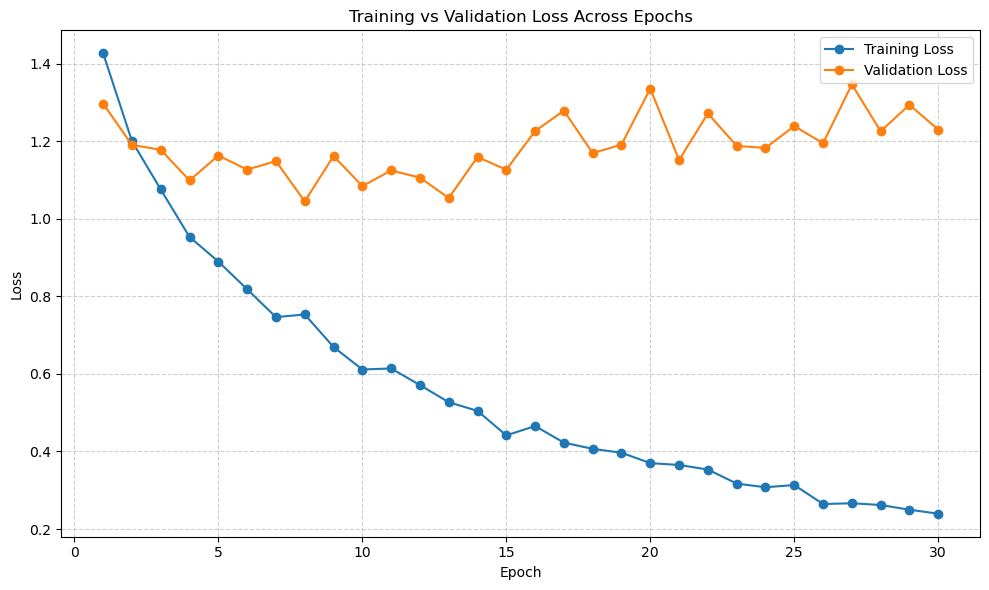

In [62]:
import matplotlib.pyplot as plt

# Manually extracted losses (30 values each)
train_loss = [
    1.4268, 1.2005, 1.0757, 0.9532, 0.8899, 0.8184,
    0.7465, 0.7533, 0.6696, 0.6114, 0.6141, 0.5713,
    0.5271, 0.5047, 0.4415, 0.4656, 0.4228, 0.4068,
    0.3968, 0.3699, 0.3652, 0.3534, 0.3172, 0.3077,
    0.3135, 0.2644, 0.2665, 0.2619, 0.2498, 0.2395
]

val_loss = [
    1.2969, 1.1905, 1.1781, 1.0991, 1.1633, 1.1270,
    1.1488, 1.0449, 1.1620, 1.0844, 1.1247, 1.1064,
    1.0537, 1.1595, 1.1267, 1.2264, 1.2789, 1.1694,
    1.1916, 1.3359, 1.1516, 1.2719, 1.1881, 1.1828,
    1.2393, 1.1950, 1.3467, 1.2258, 1.2942, 1.2300
]

epochs = list(range(1, 31))

plt.figure(figsize=(10,6))
plt.plot(epochs, train_loss, marker='o', label="Training Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")

plt.title("Training vs Validation Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(linestyle="--", alpha=.6)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# model is too complex for dataset size, overfitting occurs, as seen by divergence of training and validation metrics